Det här projektet undersöker hur ett neuralt nätverk "ser" en bild. Med hjälp av GradCAM visualiseras vilka delar av bilden som påverkar modellens beslut. Vi använder ResNet18 på ImageNet med 1000 klasser.

In [5]:
from image_analyzer import get_model, load_class_names

model = get_model()
class_names = load_class_names('imagenet_class_index.json')
print(f'Modell laddad. Antal klasser: {len(class_names)}')

Modell laddad. Antal klasser: 1000


Tre klasser analyseras: katt, pizza och skolbuss. För varje klass testas ett positivt exempel (bilden innehåller klassen) och ett negativt exempel (bilden innehåller en annan klass). Detta visar skillnaden i hur modellen fokuserar beroende på om motivet faktiskt finns i bilden.

Katten är det första exemplet. Det positiva exemplet visar en kattbild där modellen förväntas fokusera på katten. Det negativa exemplet använder en hundbild där modellen ombeds leta efter katt.

=== Katt (posotivt exempel) ===
tiger_cat                      74.31%
tabby                          19.21%
Egyptian_cat                   4.68%
lynx                           0.84%
tiger                          0.67%


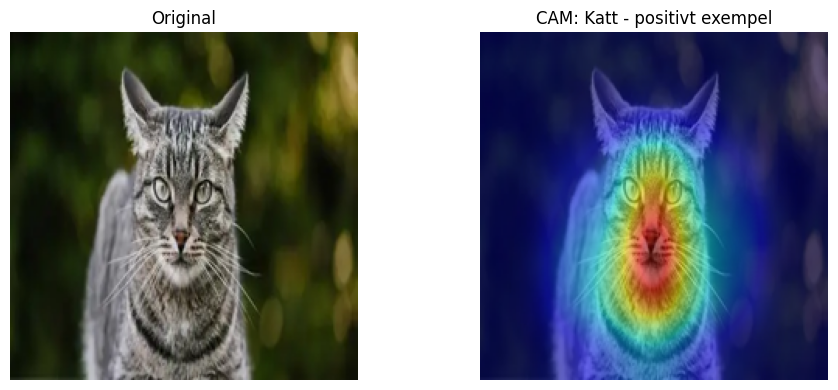

=== Katt (negativt exempel - hund) ===
German_shepherd                45.75%
timber_wolf                    7.94%
kelpie                         5.22%
kit_fox                        4.88%
grey_fox                       4.60%


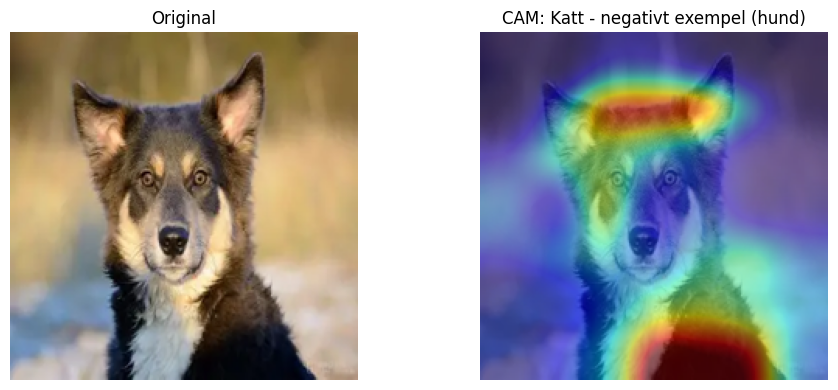

In [6]:
from image_analyzer import preprocess_image, generate_cam, get_top_predictions, show_cam

input_tensor, raw_img = preprocess_image('bilder/katt_pos.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=281)
print('=== Katt (posotivt exempel) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Katt - positivt exempel')

input_tensor, raw_img = preprocess_image('bilder/katt_neg.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=281)
print('=== Katt (negativt exempel - hund) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Katt - negativt exempel (hund)')

I det positiva exemplet fokuserar modellen på kattens ansikte och kropp. I det negativa exemplet med hunden sprids aktiveringen över hela bilden eftersom inga kattliknande drag finns.

Pizza är det andra exemplet. Det positiva exemplet visar en pizzabild och det negativa använder en bild av en klocka där modellen letar efter pizza.

=== Pizza (positivt exempel) ===
pizza                          99.84%
tray                           0.03%
pomegranate                    0.02%
frying_pan                     0.02%
potpie                         0.02%


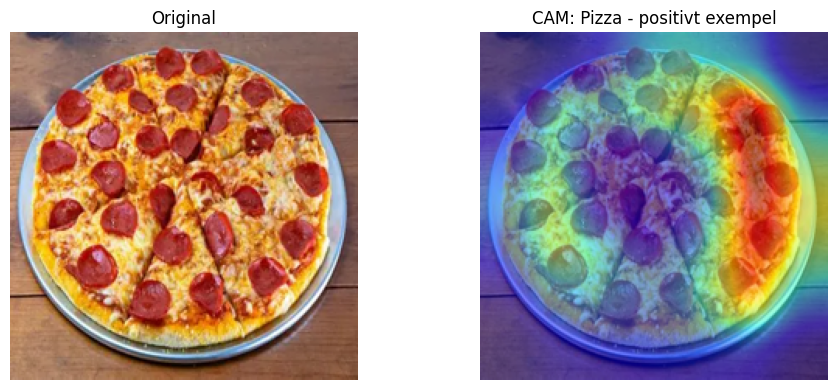

=== Pizza (negativt exempel - klocka) ===
analog_clock                   54.15%
wall_clock                     42.92%
magnetic_compass               1.30%
barometer                      0.58%
stopwatch                      0.45%


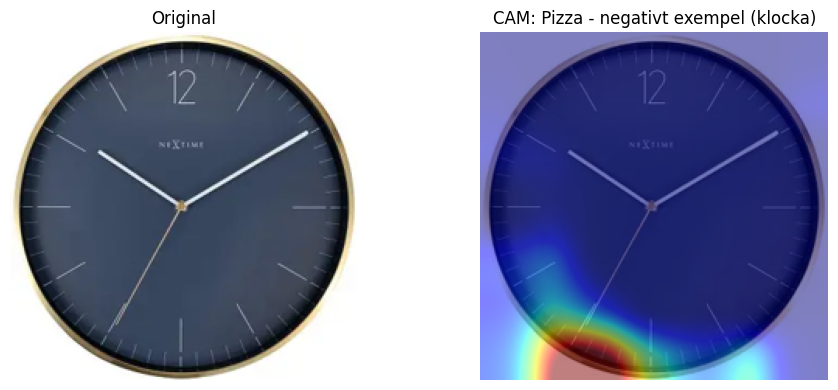

In [7]:
input_tensor, raw_img = preprocess_image('bilder/pizza_pos.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=963)
print('=== Pizza (positivt exempel) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Pizza - positivt exempel')

input_tensor, raw_img = preprocess_image('bilder/pizza_neg.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=963)
print('=== Pizza (negativt exempel - klocka) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Pizza - negativt exempel (klocka)')

I det positiva exemplet aktiveras pizzans runda form och yta. I det negativa exemplet med klockan hittar modellan inga pizzaliknande drag och aktiveringen sprids slumpmässigt.

Skolbussen är det tredje exemplet. Det positiva exemplet visar en skolbuss och det negativa använder en bild av en banan där modellen letar efter skolbuss.

=== Skolbuss (positivt exempel) ===
school_bus                     97.37%
trolleybus                     1.22%
passenger_car                  0.94%
minibus                        0.44%
streetcar                      0.03%


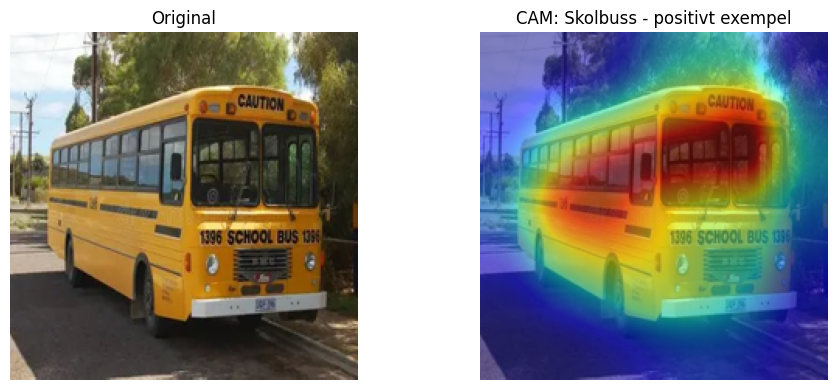

=== Skolbuss (negativt exempel - banan) ===
banana                         58.55%
hook                           10.15%
flatworm                       4.69%
nematode                       3.88%
neck_brace                     1.16%


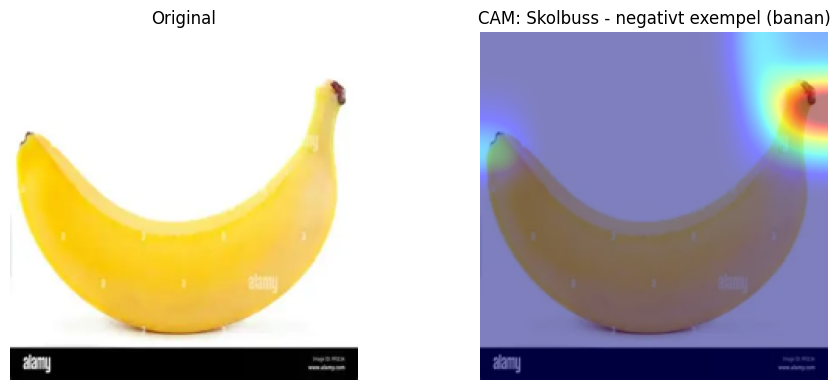

In [8]:
input_tensor, raw_img = preprocess_image('bilder/school_bus_pos.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=779)
print('=== Skolbuss (positivt exempel) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Skolbuss - positivt exempel')


input_tensor, raw_img = preprocess_image('bilder/school_bus_neg.webp')
cam_img, output = generate_cam(model, input_tensor, raw_img, target_class_idx=779)
print('=== Skolbuss (negativt exempel - banan) ===')
for name, prob in get_top_predictions(output, class_names):
    print(f'{name:<30} {prob:.2%}')
show_cam(raw_img, cam_img, title='Skolbuss - negativt exempel (banan)')

I det positiva exemplet fokuserar modellen på bussens gula färg och form med 97% säkerhet. I det negativa exemplet med bananen finns inga bussliknande drag och aktiveringen sprids ut över hela bilden.